In [1]:
"""
Yeast multi-label classification 

Key improvements over baseline:
  - ResidualMLP: skip connections + BatchNorm + GELU (no vanishing gradients)
  - Asymmetric Loss (ASL): far better than BCE for multi-label imbalance
  - Label-smoothing on positives to reduce overconfidence
  - Cosine-annealing LR with warm restarts (beats ReduceLROnPlateau here)
  - Better threshold tuning: beta-weighted F-score per label
  - Refit on full train+val uses the validated early-stop epoch count
  - Clean, modular code throughout
"""

import os, random, time, warnings
import numpy as np
import pandas as pd
import pickle
from scipy import sparse

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score, hamming_loss, accuracy_score,
    average_precision_score, precision_recall_curve, average_precision_score
)

warnings.filterwarnings("ignore")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
def seed_everything(s: int) -> None:
    random.seed(s); np.random.seed(s); torch.manual_seed(s)
    torch.cuda.manual_seed_all(s)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

# ── 1. Data loading ───────────────────────────────────────────────────────────

# ── Config ────────────────────────────────────────────────────────────────────
PKL_PATH   = "/work/gr-fe/bryan/data/SHCS/03_final/mogsage_gnn_embeddings_0.1.pkl"
THRESHOLD  = 0.5
RANDOM_STATE = 42

# ── 1. Load embeddings ────────────────────────────────────────────────────────
with open(PKL_PATH, "rb") as f:
    blob = pickle.load(f)

H         = blob["x"]          # (N, d)
train_idx = blob["train_idx"]
val_idx   = blob["val_idx"]
test_idx  = blob["test_idx"]
y         = blob["y"].astype(int)       # (N, C) multi-hot
n_labels  = y.shape[1]
label_names = blob['label_names']

# ── 2. Splits & standardisation ───────────────────────────────────────────────

print(f"Embeddings : {H.shape}")
print(f"Labels     : {y.shape}  ({n_labels} classes)")
print(f"Train/Val/Test split: {len(train_idx)} / {len(val_idx)} / {len(test_idx)}")

# ── 2. Build train / test sets (train + val → fit, test → evaluate) ───────────
fit_idx = np.concatenate([train_idx, val_idx])
X_full, y_full = H[fit_idx],    y[fit_idx]
X_tr, y_tr = H[train_idx],    y[train_idx]
X_val, y_val = H[val_idx],    y[val_idx]
X_te,  y_te  = H[test_idx],   y[test_idx]

n_feat   = X_tr.shape[1]
n_labels = y_tr.shape[1]
print(f"Features: {n_feat}, Labels: {n_labels}")

# ── 3. DataLoaders ────────────────────────────────────────────────────────────

def make_loader(X: np.ndarray, Y: np.ndarray,
                batch_size: int = 256, shuffle: bool = False) -> DataLoader:
    ds = TensorDataset(torch.from_numpy(X).float(), torch.from_numpy(Y).float())
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      pin_memory=(device.type == "cuda"), num_workers=0)

BATCH = 128
train_loader = make_loader(X_tr,   y_tr,     batch_size=BATCH, shuffle=True)
val_loader   = make_loader(X_val,  y_val,         batch_size=2048)
test_loader  = make_loader(X_te ,  y_te,    batch_size=2048)
full_loader  = make_loader(X_full, y_full,        batch_size=BATCH, shuffle=True)

# ── 4. Model: Residual MLP ────────────────────────────────────────────────────

class ResidualBlock(nn.Module):
    """
    Linear → BN → GELU → Dropout → Linear → BN, plus a learnable skip
    projection so in_dim and out_dim can differ.
    """
    def __init__(self, in_dim: int, out_dim: int, p_drop: float = 0.3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(in_dim, out_dim),
            nn.BatchNorm1d(out_dim),
            nn.GELU(),
            nn.Dropout(p_drop),
            nn.Linear(out_dim, out_dim),
            nn.BatchNorm1d(out_dim),
        )
        self.skip = (nn.Linear(in_dim, out_dim, bias=False)
                     if in_dim != out_dim else nn.Identity())
        self.act  = nn.GELU()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.act(self.block(x) + self.skip(x))


class ResidualMLP(nn.Module):
    """
    Stack of ResidualBlocks + final linear head (no activation → raw logits).
    """
    def __init__(self, in_dim: int, out_dim: int,
                 hidden: list[int] = (512, 256, 128),
                 p_drop: float = 0.3):
        super().__init__()
        dims   = [in_dim] + list(hidden)
        blocks = [ResidualBlock(dims[i], dims[i+1], p_drop) for i in range(len(dims)-1)]
        self.encoder = nn.Sequential(*blocks)
        self.head    = nn.Linear(dims[-1], out_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.head(self.encoder(x))


# ── 5. Asymmetric Loss (ASL) ──────────────────────────────────────────────────
#
# Reference: Ridnik et al., "Asymmetric Loss For Multi-Label Classification",
# ICCV 2021.  Key idea: use different γ for positives vs negatives so that
# easy negatives (the majority in multi-label) are down-weighted more
# aggressively than hard positives.

class AsymmetricLoss(nn.Module):
    def __init__(self,
                 gamma_neg: float = 4.0,   # focus on hard negatives
                 gamma_pos: float = 1.0,   # mild focus on hard positives
                 clip: float = 0.05,        # probability margin shift
                 label_smoothing: float = 0.02):
        super().__init__()
        self.gn   = gamma_neg
        self.gp   = gamma_pos
        self.clip = clip
        self.ls   = label_smoothing

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        # Soft targets with label smoothing on the positive side
        t = targets.clamp(self.ls, 1.0 - self.ls)

        xs_pos = torch.sigmoid(logits)
        xs_neg = 1.0 - xs_pos

        # Asymmetric clip: push probabilities for negatives down by `clip`
        if self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1.0)

        # BCE components
        los_pos = t       * torch.log(xs_pos.clamp(1e-8))
        los_neg = (1 - t) * torch.log(xs_neg.clamp(1e-8))

        # Asymmetric focusing weights
        with torch.no_grad():
            pt_pos = xs_pos
            pt_neg = xs_neg
        los_pos = los_pos * (1 - pt_pos) ** self.gp
        los_neg = los_neg * (1 - pt_neg) ** self.gn

        loss = -(los_pos + los_neg)
        return loss.mean()


# ── 6. Training helpers ───────────────────────────────────────────────────────

def run_epoch(model: nn.Module, loader: DataLoader,
              train: bool = True,
              optimizer=None, criterion=None):
    model.train() if train else model.eval()
    total_loss, n = 0.0, 0
    all_logits, all_targets = [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
            if train:
                optimizer.zero_grad(set_to_none=True)
            logits = model(xb)
            loss   = criterion(logits, yb)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                optimizer.step()
            bs = xb.size(0)
            total_loss += loss.item() * bs
            n          += bs
            all_logits.append(logits.detach().cpu())
            all_targets.append(yb.detach().cpu())

    logits  = torch.cat(all_logits,  0)
    targets = torch.cat(all_targets, 0)
    return total_loss / max(n, 1), logits, targets


def probs(logits: torch.Tensor) -> np.ndarray:
    return torch.sigmoid(logits).numpy()


# ── 7. Per-label threshold tuning (F-beta optimised) ─────────────────────────

def tune_thresholds(y_true: np.ndarray, y_scores: np.ndarray,
                    beta: float = 1.0,
                    default: float = 0.5) -> np.ndarray:
    """
    Find per-label threshold that maximises F-beta on the provided set.
    beta=1 → F1, beta=0.5 → precision-weighted, beta=2 → recall-weighted.
    """
    thresholds = np.full(y_true.shape[1], default, dtype=np.float32)
    for j in range(y_true.shape[1]):
        yj = y_true[:, j]
        if yj.sum() == 0:
            continue
        prec, rec, thr = precision_recall_curve(yj, y_scores[:, j])
        beta2  = beta ** 2
        fbeta  = ((1 + beta2) * prec[:-1] * rec[:-1]
                  / (beta2 * prec[:-1] + rec[:-1] + 1e-12))
        if np.any(np.isfinite(fbeta)):
            thresholds[j] = thr[np.nanargmax(fbeta)]
    return thresholds


def evaluate(y_true: np.ndarray, y_scores: np.ndarray,
             thresholds=None) -> tuple[dict, np.ndarray]:
    thr    = 0.5 if thresholds is None else thresholds
    y_pred = (y_scores >= thr).astype(int)
    metrics = {
        "F1-micro":    f1_score(y_true, y_pred, average="micro",  zero_division=0),
        "F1-macro":    f1_score(y_true, y_pred, average="macro",  zero_division=0),
        "mAP-micro":   average_precision_score(y_true, y_scores, average="micro"),
        "mAP-macro":   average_precision_score(y_true, y_scores, average="macro"),
        "HammingLoss": hamming_loss(y_true, y_pred),
        "SubsetAcc":   accuracy_score(y_true, y_pred),
    }
    return metrics, y_pred


def print_metrics(metrics: dict, title: str = "") -> None:
    if title:
        print(f"\n{title}")
    for k, v in metrics.items():
        print(f"  {k:>13}: {v:.4f}")


# ── 8. Build model & optimiser ────────────────────────────────────────────────

def build_model_and_opt(n_feat: int, n_labels: int,
                        hidden=(512, 256, 128), p_drop=0.4, lr=5e-5):
    m = ResidualMLP(n_feat, n_labels, hidden=hidden, p_drop=p_drop).to(device)
    opt = torch.optim.AdamW(m.parameters(), lr=lr, weight_decay=1e-4)
    return m, opt

criterion = AsymmetricLoss(gamma_neg=4, gamma_pos=1, clip=0.05, label_smoothing=0.02)

model, optimizer = build_model_and_opt(n_feat, n_labels)

# Cosine annealing with warm restarts
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=60, T_mult=2, eta_min=1e-6)

# ── 9. Training loop with early stopping ─────────────────────────────────────

history = {"epoch": [], "tr_loss": [], "val_loss": [], "val_f1_micro": [], "val_map_micro": [], "lr": []}

MAX_EPOCHS   = 500
PATIENCE     = 40          # epochs without val improvement before stopping
MONITOR      = "f1_micro"  # "val_loss" or "f1_micro"

best_score   = -np.inf if MONITOR == "f1_micro" else np.inf
best_state   = None
best_epoch   = 0
no_improve   = 0

t0 = time.time()
for epoch in range(1, MAX_EPOCHS + 1):
    tr_loss, _, _               = run_epoch(model, train_loader, train=True,
                                            optimizer=optimizer, criterion=criterion)
    val_loss, val_logits, val_t = run_epoch(model, val_loader,   train=False,
                                            criterion=criterion)
    scheduler.step(epoch)

    val_scores = probs(val_logits)
    val_np     = val_t.numpy()
    val_f1     = f1_score(val_np, (val_scores >= 0.5).astype(int),
                          average="micro", zero_division=0)
    val_map    = average_precision_score(val_np, val_scores, average="micro")

    # Track history
    history["epoch"].append(epoch)
    history["tr_loss"].append(float(tr_loss))
    history["val_loss"].append(float(val_loss))
    history["val_f1_micro"].append(float(val_f1))
    history["val_map_micro"].append(float(val_map))
    history["lr"].append(float(optimizer.param_groups[0]["lr"]))

    score = val_f1 if MONITOR == "f1_micro" else -val_loss
    improved = score > best_score + 1e-5

    if improved:
        best_score  = score
        best_epoch  = epoch
        best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        no_improve  = 0
    else:
        no_improve += 1

    if epoch % 20 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]["lr"]
        print(f"Epoch {epoch:03d} | tr {tr_loss:.4f} | val {val_loss:.4f} "
              f"| val F1 {val_f1:.4f} | lr {lr_now:.2e}")

    if no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch} (best epoch: {best_epoch})")
        break

print(f"Training wall time: {time.time()-t0:.1f}s")
model.load_state_dict({k: v.to(device) for k, v in best_state.items()})

# ── 10. Threshold tuning on validation set ───────────────────────────────────

with torch.no_grad():
    _, val_logits, val_t = run_epoch(model, val_loader, train=False, criterion=criterion)
val_scores = probs(val_logits)
val_np     = val_t.numpy()

thresholds = tune_thresholds(val_np, val_scores, beta=1.0, default=0.5)
print("\nPer-label tuned thresholds:", np.round(thresholds, 3))

# Quick val metrics to see gain from tuning
m_05, _    = evaluate(val_np, val_scores, thresholds=None)
m_tuned, _ = evaluate(val_np, val_scores, thresholds=thresholds)
print_metrics(m_05,    "Val — threshold=0.5")
print_metrics(m_tuned, "Val — per-label tuned")

# ── 11. Refit on full train+val for exactly `best_epoch` epochs ──────────────
#
# We know from the validation-monitored run that the model peaked at
# `best_epoch`. Refitting for that many epochs avoids both the overfitting
# that would happen with an arbitrary 100-epoch budget AND the instability
# of stopping on train-loss alone.

print(f"\nRefitting on full train+val for {best_epoch} epochs…")
model_final, opt_final = build_model_and_opt(n_feat, n_labels)
sched_final = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    opt_final, T_0=30, T_mult=2, eta_min=1e-6)

t0 = time.time()
for epoch in range(1, best_epoch + 1):
    tr_loss, _, _ = run_epoch(model_final, full_loader, train=True,
                              optimizer=opt_final, criterion=criterion)
    sched_final.step(epoch)
    if epoch % 20 == 0 or epoch == best_epoch:
        print(f"  [full-train] epoch {epoch:03d} | loss {tr_loss:.4f}")

print(f"Refit wall time: {time.time()-t0:.1f}s")

# ── 12. Test evaluation ───────────────────────────────────────────────────────

with torch.no_grad():
    _, te_logits, te_t = run_epoch(model_final, test_loader, train=False, criterion=criterion)
y_scores_te = probs(te_logits)
y_true_te   = te_t.numpy()

m_05_te, y_pred_05        = evaluate(y_true_te, y_scores_te, thresholds=None)
m_tuned_te, y_pred_tuned  = evaluate(y_true_te, y_scores_te, thresholds=thresholds)

print_metrics(m_05_te,    "Test — threshold=0.5")
print_metrics(m_tuned_te, "Test — per-label tuned thresholds")

# ── 13. Per-label report ──────────────────────────────────────────────────────

per_f1 = f1_score(y_true_te, y_pred_tuned, average=None, zero_division=0)
per_ap = [average_precision_score(y_true_te[:, j], y_scores_te[:, j])
          for j in range(n_labels)]
freq   = y_true_te.sum(0)

lnames = [str(l) for l in label_names]
report = (pd.DataFrame({"label": lnames,
                        "freq_test": freq,
                        "F1_tuned": per_f1,
                        "AP": per_ap,
                        "threshold": thresholds})
          .sort_values("freq_test", ascending=False)
          .reset_index(drop=True))

print("\nPer-label report (sorted by test frequency):")
print(report.to_string(index=False))

Device: cuda
Embeddings : (2078, 5792)
Labels     : (2078, 5)  (5 classes)
Train/Val/Test split: 1246 / 415 / 417
Features: 5792, Labels: 5
Epoch 001 | tr 0.1259 | val 0.1102 | val F1 0.3603 | lr 5.00e-05
Epoch 020 | tr 0.0557 | val 0.0968 | val F1 0.5117 | lr 3.78e-05
Epoch 040 | tr 0.0350 | val 0.1032 | val F1 0.5174 | lr 1.33e-05
Epoch 060 | tr 0.0329 | val 0.1051 | val F1 0.5197 | lr 5.00e-05
Early stopping at epoch 64 (best epoch: 24)
Training wall time: 8.9s

Per-label tuned thresholds: [0.551 0.512 0.544 0.574 0.5  ]

Val — threshold=0.5
       F1-micro: 0.5273
       F1-macro: 0.5052
      mAP-micro: 0.5273
      mAP-macro: 0.5035
    HammingLoss: 0.3499
      SubsetAcc: 0.1614

Val — per-label tuned
       F1-micro: 0.5409
       F1-macro: 0.5241
      mAP-micro: 0.5273
      mAP-macro: 0.5035
    HammingLoss: 0.2920
      SubsetAcc: 0.2217

Refitting on full train+val for 24 epochs…
  [full-train] epoch 020 | loss 0.0577
  [full-train] epoch 024 | loss 0.0543
Refit wall time:

In [6]:
def per_class_metrics_from_scores(y_pred: np.ndarray,
                                 y_true: np.ndarray,
                                 threshold: float = 0.5,
                                 assume_one_hot_true: bool = False):
    """
    Compute per-class accuracy, F1 (micro), and F1 (macro) for multi-label or one-vs-rest framing.

    Parameters
    ----------
    y_pred : (H, C) array
        Predicted scores/probabilities (or already-binary predictions).
    y_true : (H, C) array
        Ground-truth labels. If `assume_one_hot_true=True`, it should be one-hot (single-label).
        Otherwise it can be multi-hot (multi-label).
    threshold : float
        Threshold used to binarize y_pred if it is not already {0,1}.
    assume_one_hot_true : bool
        If True, y_true is treated as one-hot and will be converted to binary per class naturally.
        If False, y_true is assumed already binary multi-label (0/1).

    Returns
    -------
    metrics : dict
        {
          "per_class": {
             "accuracy": (C,),
             "f1_micro": (C,),
             "f1_macro": (C,),
             "precision": (C,),
             "recall": (C,),
             "support_pos": (C,),  # number of positives in y_true per class
          },
          "confusion": {
             "tp": (C,), "fp": (C,), "fn": (C,), "tn": (C,)
          }
        }

    Notes
    -----
    For each class k, we treat it as a binary problem (class k vs not-k):
      TP_k, FP_k, FN_k, TN_k
    Per-class micro-F1 equals the binary F1 for that class:
      F1_micro_k = 2*TP_k / (2*TP_k + FP_k + FN_k)
    Per-class macro-F1 is the average of positive-class F1 and negative-class F1:
      F1_macro_k = (F1_pos_k + F1_neg_k)/2
    """
    y_pred = np.asarray(y_pred)
    y_true = np.asarray(y_true)

    if y_pred.shape != y_true.shape or y_pred.ndim != 2:
        raise ValueError(f"Expected y_pred and y_true to have same shape (H, C). "
                         f"Got {y_pred.shape=} and {y_true.shape=}.")

    H, C = y_true.shape

    # Binarize predictions if needed
    if np.issubdtype(y_pred.dtype, np.floating) or np.any((y_pred != 0) & (y_pred != 1)):
        y_pred_bin = (y_pred >= threshold).astype(np.int64)
    else:
        y_pred_bin = y_pred.astype(np.int64)

    # Ensure y_true is binary
    if assume_one_hot_true:
        # Allow one-hot ints or floats; treat >0 as 1
        y_true_bin = (y_true > 0).astype(np.int64)
    else:
        y_true_bin = y_true.astype(np.int64)
        if np.any((y_true_bin != 0) & (y_true_bin != 1)):
            raise ValueError("y_true must be binary (0/1) when assume_one_hot_true=False.")

    # Confusion terms per class (vectorised)
    tp = np.sum((y_pred_bin == 1) & (y_true_bin == 1), axis=0)
    fp = np.sum((y_pred_bin == 1) & (y_true_bin == 0), axis=0)
    fn = np.sum((y_pred_bin == 0) & (y_true_bin == 1), axis=0)
    tn = np.sum((y_pred_bin == 0) & (y_true_bin == 0), axis=0)

    # Per-class accuracy
    acc = (tp + tn) / (tp + fp + fn + tn)

    # Precision/Recall for positive class (per class)
    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype=float), where=(tp + fp) != 0)
    recall    = np.divide(tp, tp + fn, out=np.zeros_like(tp, dtype=float), where=(tp + fn) != 0)

    # Per-class F1 (micro == binary F1 for this one-vs-rest class)
    f1_micro = np.divide(
        2 * tp, 2 * tp + fp + fn,
        out=np.zeros_like(tp, dtype=float),
        where=(2 * tp + fp + fn) != 0
    )

    # Negative-class F1 (treat "not class k" as positive), then macro-average within the class.
    precision_neg = np.divide(tn, tn + fn, out=np.zeros_like(tn, dtype=float), where=(tn + fn) != 0)
    recall_neg    = np.divide(tn, tn + fp, out=np.zeros_like(tn, dtype=float), where=(tn + fp) != 0)
    f1_neg = np.divide(
        2 * precision_neg * recall_neg, precision_neg + recall_neg,
        out=np.zeros_like(precision_neg, dtype=float),
        where=(precision_neg + recall_neg) != 0
    )

    f1_macro = 0.5 * (f1_micro + f1_neg)

    return {
        "per_class": {
            "accuracy": acc,
            "f1_micro": f1_micro,
            "f1_macro": f1_macro,
            "precision": precision,
            "recall": recall,
            "support_pos": np.sum(y_true_bin == 1, axis=0),
        },
        "confusion": {"tp": tp, "fp": fp, "fn": fn, "tn": tn},
    }


# Example usage:
# metrics = per_class_metrics_from_scores(y_pred, y_true, threshold=0.5)
# print(metrics["per_class"]["accuracy"])  # shape (C,)
# print(metrics["per_class"]["f1_micro"])  # shape (C,)
# print(metrics["per_class"]["f1_macro"])  # shape (C,)


In [7]:
per_class_metrics_from_scores((y_scores_te > 0.5)*1 , y_true_te)

{'per_class': {'accuracy': array([0.5971223 , 0.66426859, 0.65947242, 0.5059952 , 0.70503597]),
  'f1_micro': array([0.42465753, 0.46969697, 0.41803279, 0.62681159, 0.28901734]),
  'f1_macro': array([0.55734722, 0.61204147, 0.58867741, 0.44815757, 0.55146782]),
  'precision': array([0.29807692, 0.39240506, 0.30909091, 0.46505376, 0.25510204]),
  'recall': array([0.73809524, 0.58490566, 0.64556962, 0.96111111, 0.33333333]),
  'support_pos': array([ 84, 106,  79, 180,  75])},
 'confusion': {'tp': array([ 62,  62,  51, 173,  25]),
  'fp': array([146,  96, 114, 199,  73]),
  'fn': array([22, 44, 28,  7, 50]),
  'tn': array([187, 215, 224,  38, 269])}}

In [5]:
(y_scores_te > 0.5)*1

array([[1, 1, 1, 1, 0],
       [1, 0, 0, 1, 0],
       [0, 0, 0, 1, 0],
       ...,
       [0, 0, 1, 1, 1],
       [0, 0, 0, 1, 0],
       [1, 0, 1, 1, 0]], shape=(417, 5))

In [4]:
 evaluate(y_true_te, y_scores_te, thresholds=None)

({'F1-micro': 0.48918032786885246,
  'F1-macro': 0.4456432452144304,
  'mAP-micro': 0.4679296821116993,
  'mAP-macro': 0.4292761241436719,
  'HammingLoss': 0.373621103117506,
  'SubsetAcc': 0.15587529976019185},
 array([[1, 1, 1, 1, 0],
        [1, 0, 0, 1, 0],
        [0, 0, 0, 1, 0],
        ...,
        [0, 0, 1, 1, 1],
        [0, 0, 0, 1, 0],
        [1, 0, 1, 1, 0]], shape=(417, 5)))

In [6]:
import sys
sys.path.insert(0 , '../MAIN/')
from train import evaluate_multilabel

In [8]:
y_true_te

array([[0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.],
       ...,
       [0., 1., 0., 0., 1.],
       [0., 0., 0., 1., 0.],
       [0., 0., 0., 1., 0.]], shape=(417, 5), dtype=float32)

array([[1, 1, 1, 1, 0],
       [1, 0, 0, 1, 0],
       [0, 0, 0, 1, 0],
       ...,
       [0, 0, 1, 1, 1],
       [0, 0, 0, 1, 0],
       [1, 0, 1, 1, 0]], shape=(417, 5))

In [12]:
evaluate_multilabel(y_true_te, (y_scores_te > 0.5)*1)

{'Model': 'Model',
 'Hamming Loss': 0.3736,
 'Exact Match': 0.1559,
 'Micro F1': 0.4892,
 'Macro F1': 0.4456,
 'Sample F1': 0.5127,
 'Jaccard': 0.4092}

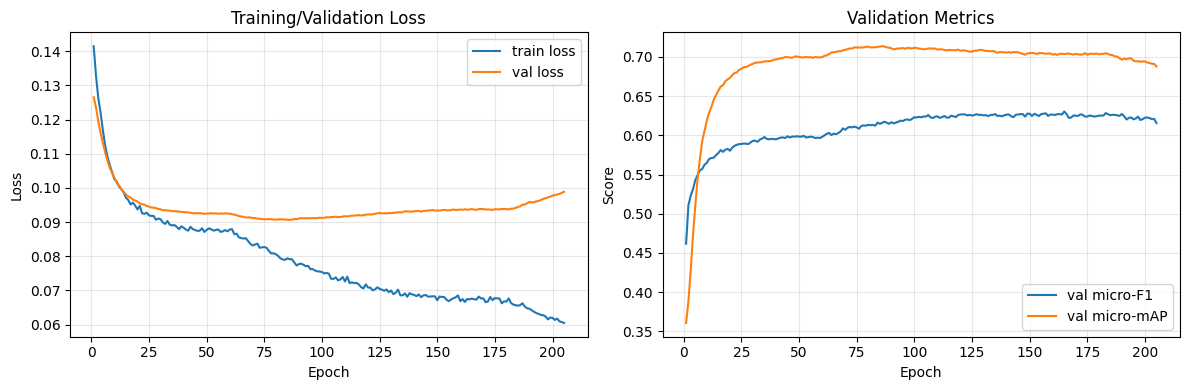

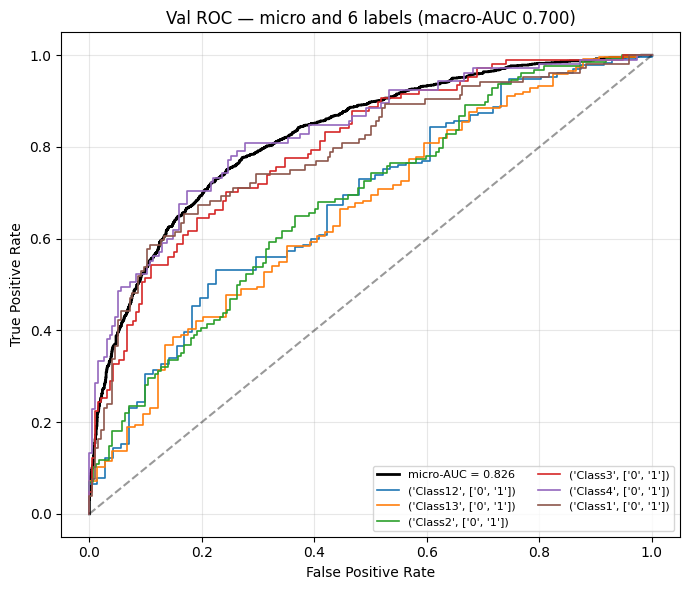

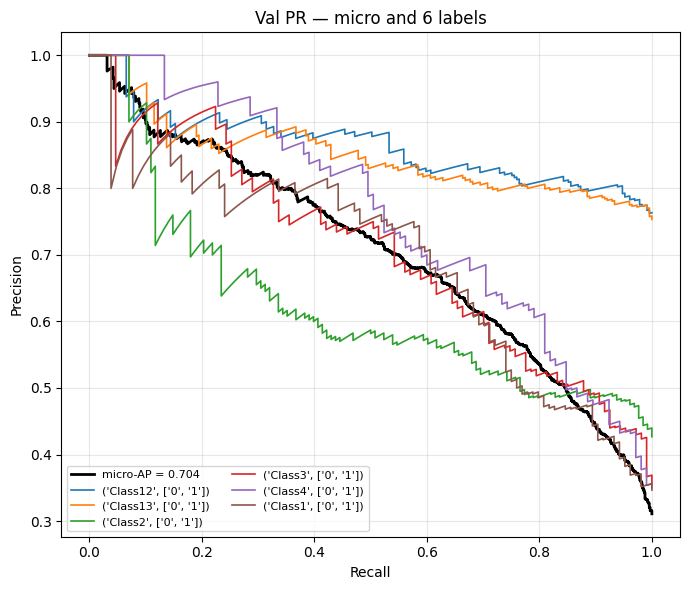

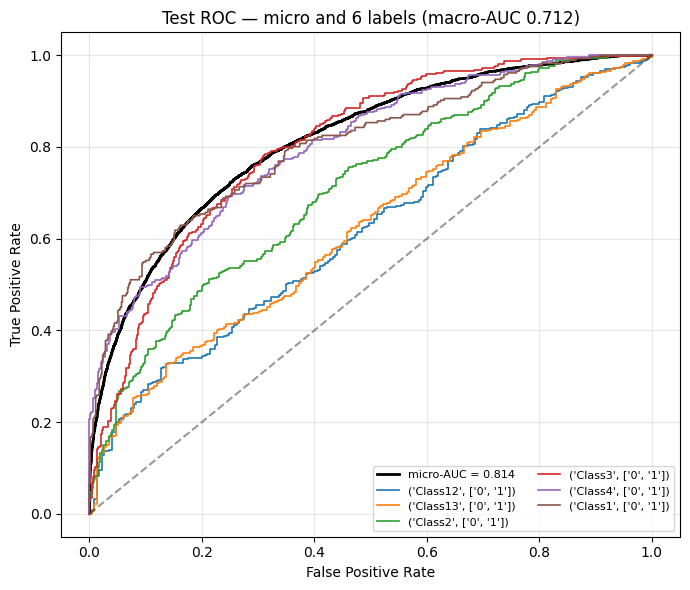

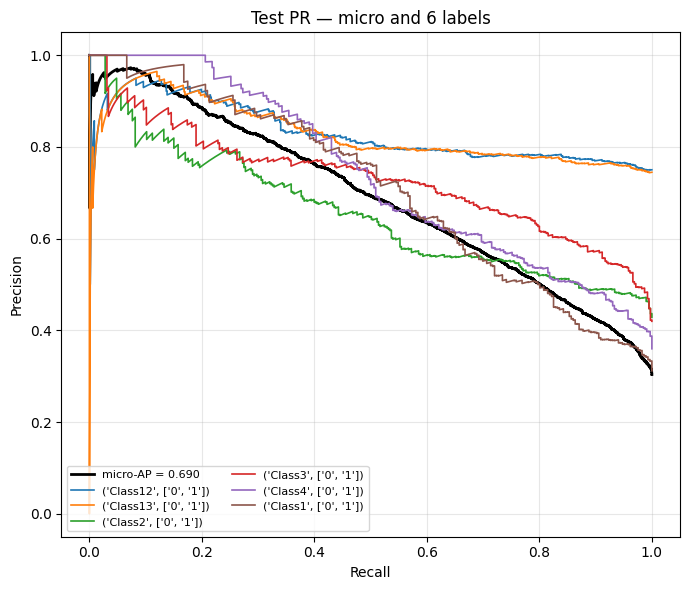

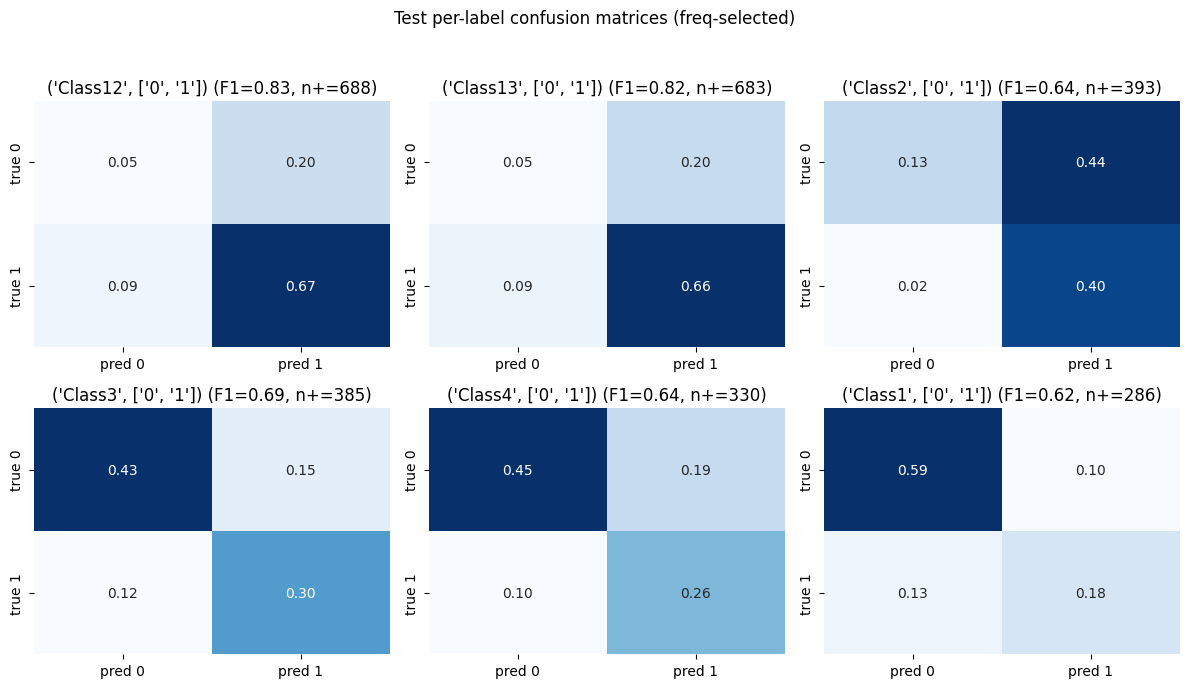

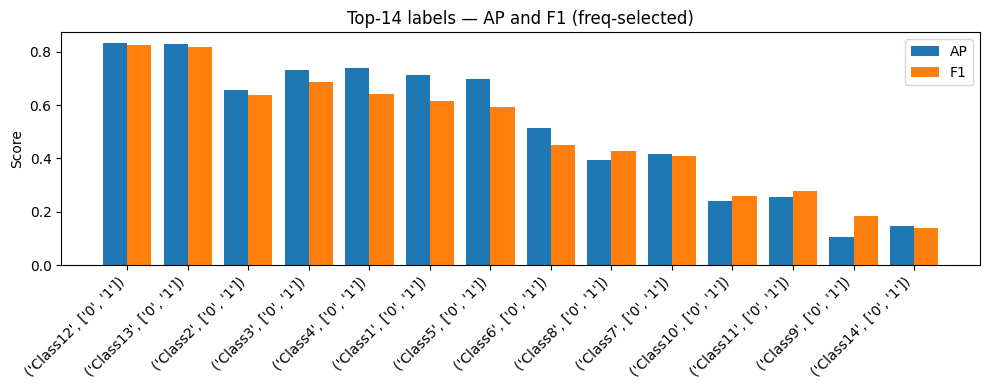

In [3]:
# ── Plotting utilities ────────────────────────────────────────────────────────
# If missing, install: pip install matplotlib seaborn

import matplotlib.pyplot as plt
try:
    import seaborn as sns
except ImportError:
    sns = None

from sklearn.metrics import roc_curve, auc, roc_auc_score, precision_recall_curve, multilabel_confusion_matrix

os.makedirs("figs", exist_ok=True)

def plot_training_curves(history):
    epochs = history["epoch"]
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    # Loss
    ax[0].plot(epochs, history["tr_loss"], label="train loss")
    ax[0].plot(epochs, history["val_loss"], label="val loss")
    ax[0].set_title("Training/Validation Loss")
    ax[0].set_xlabel("Epoch"); ax[0].set_ylabel("Loss"); ax[0].legend(); ax[0].grid(True, alpha=0.3)
    # Metrics
    ax[1].plot(epochs, history["val_f1_micro"], label="val micro-F1")
    ax[1].plot(epochs, history["val_map_micro"], label="val micro-mAP")
    ax[1].set_title("Validation Metrics")
    ax[1].set_xlabel("Epoch"); ax[1].set_ylabel("Score"); ax[1].legend(); ax[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig("figs/training_curves.png", dpi=150)
    plt.show()

def select_labels_for_plots(y_true, y_scores, label_names, k=6, mode="freq"):
    # mode = "freq" (most common) or "ap" (highest AP)
    freq = y_true.sum(axis=0).astype(int)
    ap = np.array([average_precision_score(y_true[:, j], y_scores[:, j]) for j in range(y_true.shape[1])])
    if mode == "ap":
        idx = np.argsort(-ap)[:k]
    else:
        idx = np.argsort(-freq)[:k]
    names = [str(label_names[i]) for i in idx]
    return idx, names, freq, ap

def plot_roc_curves(y_true, y_scores, label_names, k=6, mode="freq", title_prefix="Val"):
    # Micro-average
    fpr_micro, tpr_micro, _ = roc_curve(y_true.ravel(), y_scores.ravel())
    auc_micro = auc(fpr_micro, tpr_micro)
    auc_macro = roc_auc_score(y_true, y_scores, average="macro")

    idx, names, freq, ap = select_labels_for_plots(y_true, y_scores, label_names, k=k, mode=mode)
    plt.figure(figsize=(7, 6))
    plt.plot(fpr_micro, tpr_micro, color="black", lw=2, label=f"micro-AUC = {auc_micro:.3f}")
    # Per-label
    for i, name in zip(idx, names):
        fpr, tpr, _ = roc_curve(y_true[:, i], y_scores[:, i])
        plt.plot(fpr, tpr, lw=1.2, label=f"{name}")
    plt.plot([0,1],[0,1],'k--',alpha=0.4)
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"{title_prefix} ROC — micro and {len(idx)} labels (macro-AUC {auc_macro:.3f})")
    plt.legend(loc="lower right", fontsize=8, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"figs/{title_prefix.lower().replace(' ','_')}_roc.png", dpi=150)
    plt.show()

def plot_pr_curves(y_true, y_scores, label_names, k=6, mode="freq", title_prefix="Val"):
    ap_micro = average_precision_score(y_true, y_scores, average="micro")
    idx, names, freq, ap = select_labels_for_plots(y_true, y_scores, label_names, k=k, mode=mode)
    plt.figure(figsize=(7, 6))
    precision, recall, _ = precision_recall_curve(y_true.ravel(), y_scores.ravel())
    plt.plot(recall, precision, color="black", lw=2, label=f"micro-AP = {ap_micro:.3f}")
    for i, name in zip(idx, names):
        p, r, _ = precision_recall_curve(y_true[:, i], y_scores[:, i])
        plt.plot(r, p, lw=1.2, label=f"{name}")
    plt.xlabel("Recall"); plt.ylabel("Precision")
    plt.title(f"{title_prefix} PR — micro and {len(idx)} labels")
    plt.legend(loc="lower left", fontsize=8, ncol=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"figs/{title_prefix.lower().replace(' ','_')}_pr.png", dpi=150)
    plt.show()

def plot_multilabel_confusion(y_true, y_pred, label_names, k=6, mode="freq", normalize=False, title_prefix="Test"):
    mcm = multilabel_confusion_matrix(y_true, y_pred)
    freq = y_true.sum(axis=0).astype(int)
    f1 = f1_score(y_true, y_pred, average=None, zero_division=0)
    if mode == "f1":
        idx = np.argsort(-f1)[:k]
    else:
        idx = np.argsort(-freq)[:k]
    names = [str(label_names[i]) for i in idx]

    cols = 3
    rows = int(np.ceil(k / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(4*cols, 3.6*rows))
    axes = np.array(axes).reshape(-1)
    for ax, i, name in zip(axes, idx, names):
        tn, fp, fn, tp = mcm[i].ravel()
        cm = np.array([[tn, fp],[fn, tp]], dtype=float)
        if normalize:
            cm = cm / cm.sum()
            fmt = ".2f"
        else:
            fmt = "d"
        if sns is not None:
            sns.heatmap(cm, annot=True, fmt=fmt, cbar=False, ax=ax,
                        xticklabels=["pred 0", "pred 1"],
                        yticklabels=["true 0", "true 1"],
                        cmap="Blues")
        else:
            im = ax.imshow(cm, cmap="Blues"); 
            for (ii, jj), v in np.ndenumerate(cm):
                ax.text(jj, ii, f"{v:{fmt}}", ha="center", va="center")
        ax.set_title(f"{name} (F1={f1[i]:.2f}, n+={freq[i]})")
        ax.set_xlabel(""); ax.set_ylabel("")
    # Hide any unused subplots
    for j in range(len(idx), len(axes)):
        axes[j].axis("off")
    plt.suptitle(f"{title_prefix} per-label confusion matrices ({mode}-selected)")
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"figs/{title_prefix.lower().replace(' ','_')}_confusion_{mode}.png", dpi=150)
    plt.show()

def plot_perlabel_bars(per_ap, per_f1, label_names, top=10, mode="freq", y_true=None):
    # Choose labels by frequency (default) or AP
    if mode == "ap":
        idx = np.argsort(-np.array(per_ap))[:top]
    else:
        idx = np.argsort(-y_true.sum(axis=0))[:top]
    names = [str(label_names[i]) for i in idx]
    x = np.arange(len(idx))
    w = 0.4
    plt.figure(figsize=(10, 4))
    plt.bar(x - w/2, np.array(per_ap)[idx], width=w, label="AP")
    plt.bar(x + w/2, np.array(per_f1)[idx], width=w, label="F1")
    plt.xticks(x, names, rotation=45, ha="right")
    plt.ylabel("Score")
    plt.title(f"Top-{len(idx)} labels — AP and F1 ({mode}-selected)")
    plt.legend(); plt.tight_layout()
    plt.savefig("figs/perlabel_bars.png", dpi=150)
    plt.show()

# ── Generate plots ────────────────────────────────────────────────────────────

# 1) Training curves (uses tracked history)
plot_training_curves(history)

# 2) Validation curves (before refit) — recompute if needed
with torch.no_grad():
    _, val_logits2, val_t2 = run_epoch(model, val_loader, train=False, criterion=criterion)
val_scores2 = probs(val_logits2); val_np2 = val_t2.numpy()
plot_roc_curves(val_np2, val_scores2, label_names, k=6, mode="freq", title_prefix="Val")
plot_pr_curves (val_np2, val_scores2, label_names, k=6, mode="freq", title_prefix="Val")

# 3) Test curves (after refit)
plot_roc_curves(y_true_te, y_scores_te, label_names, k=6, mode="freq", title_prefix="Test")
plot_pr_curves (y_true_te, y_scores_te, label_names, k=6, mode="freq", title_prefix="Test")

# 4) Confusion matrices on test predictions (use tuned thresholds)
plot_multilabel_confusion(y_true_te, y_pred_tuned, label_names, k=6, mode="freq", normalize=True, title_prefix="Test")

# 5) Per-label bars: AP and F1 (from your per-label report variables)
# If you already computed per_f1 and per_ap above, reuse them, else recompute:
per_f1 = f1_score(y_true_te, y_pred_tuned, average=None, zero_division=0)
per_ap = [average_precision_score(y_true_te[:, j], y_scores_te[:, j]) for j in range(n_labels)]
plot_perlabel_bars(per_ap, per_f1, label_names, top=15, mode="freq", y_true=y_true_te)